# 03 - Sales Forecasting Model

Predict daily `Revenue` and `COGS` for `2023-01-01` to `2024-07-01`.

This notebook is organized as a single reproducible training workflow:

1. Data preparation
2. Feature engineering
3. Validation design
4. Model training
5. Forecast generation
6. Explainability
7. Reproducibility artifacts

## 1. Data Preparation

The released analytical `sales.csv` is already processed as a daily table. This section only:

- Parses `Date`
- Sorts chronologically
- Keeps the daily sales table in the expected modeling shape


In [1]:
from __future__ import annotations

import json
import math
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "analytical"
MODEL_DIR = PROJECT_ROOT / "models"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
REPORT_DIR = PROJECT_ROOT / "reports" / "tables"

SALES_PATH = DATA_DIR / "sales.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"
SUBMISSION_PATH = SUBMISSION_DIR / "submission_03_sales_forecast.csv"
VALIDATION_RESULTS_PATH = REPORT_DIR / "03_sales_forecast_validation_results.csv"
MODEL_CONFIG_PATH = MODEL_DIR / "03_sales_forecast_model_config.json"
FEATURE_IMPORTANCE_PATH = REPORT_DIR / "03_sales_forecast_feature_importance.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLS = ["Revenue", "COGS"]
LAGS = [1, 7, 14, 30, 365]
ROLLING_WINDOWS = [7, 30, 90, 365]
FORECAST_START = pd.Timestamp("2023-01-01")
FORECAST_END = pd.Timestamp("2024-07-01")
VALIDATION_YEAR = 2022

In [2]:
sales_raw = pd.read_csv(SALES_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

sales_raw["Date"] = pd.to_datetime(sales_raw["Date"])
sample_submission["Date"] = pd.to_datetime(sample_submission["Date"])

sales_raw = sales_raw.sort_values("Date").reset_index(drop=True)
sample_submission = sample_submission.sort_values("Date").reset_index(drop=True)

print("Sales shape:", sales_raw.shape)
print("Sales date range:", sales_raw["Date"].min().date(), "to", sales_raw["Date"].max().date())
print("Sample submission shape:", sample_submission.shape)
print("Submission date range:", sample_submission["Date"].min().date(), "to", sample_submission["Date"].max().date())
sales_raw.head()

Sales shape: (3833, 3)
Sales date range: 2012-07-04 to 2022-12-31
Sample submission shape: (548, 3)
Submission date range: 2023-01-01 to 2024-07-01


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [5]:
# The analytical sales file is already a processed daily table, so no missing-date filling or imputation is applied.
daily_sales = sales_raw[["Date", *TARGET_COLS]].copy()

assert daily_sales["Date"].is_monotonic_increasing
assert daily_sales[TARGET_COLS].notna().all().all()
assert not daily_sales["Date"].duplicated().any()

print("Daily sales table:", daily_sales.shape)
daily_sales.tail()


Daily sales table: (3833, 3)
Filled missing target rows: 0


,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


## 2. Feature Engineering

Features are designed to avoid target leakage:

- Calendar features are known in advance.
- Cyclical features encode day/week/month/annual seasonality.
- Lag features use only previous observed or previously predicted values.
- Rolling features are shifted by one day, so the current target value is never used to predict itself.
- Optional internal exogenous features are based on shifted historical target relationships only.

In [6]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = out["Date"].dt
    iso = dt.isocalendar()

    out["year"] = dt.year
    out["quarter"] = dt.quarter
    out["month"] = dt.month
    out["weekofyear"] = iso.week.astype(int)
    out["dayofyear"] = dt.dayofyear
    out["dayofmonth"] = dt.day
    out["dayofweek"] = dt.dayofweek
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    out["is_month_start"] = dt.is_month_start.astype(int)
    out["is_month_end"] = dt.is_month_end.astype(int)
    out["is_quarter_start"] = dt.is_quarter_start.astype(int)
    out["is_quarter_end"] = dt.is_quarter_end.astype(int)
    out["is_year_start"] = dt.is_year_start.astype(int)
    out["is_year_end"] = dt.is_year_end.astype(int)
    return out


def add_cyclical_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    cycles = {
        "dayofweek": 7,
        "dayofyear": 366,
        "month": 12,
        "weekofyear": 53,
    }
    for col, period in cycles.items():
        angle = 2 * np.pi * out[col] / period
        out[f"{col}_sin"] = np.sin(angle)
        out[f"{col}_cos"] = np.cos(angle)
    return out


def add_lag_rolling_features(df: pd.DataFrame, target_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for target in target_cols:
        shifted = out[target].shift(1)
        for lag in LAGS:
            out[f"{target}_lag_{lag}"] = out[target].shift(lag)
        for window in ROLLING_WINDOWS:
            out[f"{target}_roll_mean_{window}"] = shifted.rolling(window, min_periods=max(2, window // 3)).mean()
            out[f"{target}_roll_std_{window}"] = shifted.rolling(window, min_periods=max(2, window // 3)).std()
            out[f"{target}_roll_min_{window}"] = shifted.rolling(window, min_periods=max(2, window // 3)).min()
            out[f"{target}_roll_max_{window}"] = shifted.rolling(window, min_periods=max(2, window // 3)).max()

    # Leakage-safe internal exogenous features: all are shifted or historical expanding values.
    out["gross_margin_lag_1"] = (out["Revenue"].shift(1) - out["COGS"].shift(1))
    out["cogs_to_revenue_lag_1"] = out["COGS"].shift(1) / out["Revenue"].shift(1).replace(0, np.nan)
    out["revenue_expanding_mean"] = out["Revenue"].shift(1).expanding(min_periods=30).mean()
    out["cogs_expanding_mean"] = out["COGS"].shift(1).expanding(min_periods=30).mean()
    return out


def make_features(df: pd.DataFrame, target_cols: list[str] = TARGET_COLS) -> pd.DataFrame:
    out = add_calendar_features(df)
    out = add_cyclical_features(out)
    out = add_lag_rolling_features(out, target_cols)
    return out

feature_table = make_features(daily_sales)
feature_cols = [c for c in feature_table.columns if c not in ["Date", *TARGET_COLS]]
model_table = feature_table.dropna(subset=feature_cols + TARGET_COLS).reset_index(drop=True)

print("Feature table shape:", feature_table.shape)
print("Model-ready table shape:", model_table.shape)
print("Feature count:", len(feature_cols))
model_table[["Date", *TARGET_COLS] + feature_cols[:8]].head()

Feature table shape: (3833, 71)
Model-ready table shape: (3468, 71)
Feature count: 68


,Date,Revenue,COGS,year,quarter,month,weekofyear,dayofyear,dayofmonth,dayofweek,is_weekend
0,2013-07-04,2521315.44,2408274.98,2013,3,7,27,185,4,3,0
1,2013-07-05,2494107.65,2432073.97,2013,3,7,27,186,5,4,0
2,2013-07-06,2452372.43,2331799.51,2013,3,7,27,187,6,5,1
3,2013-07-07,2958215.01,2950992.63,2013,3,7,27,188,7,6,1
4,2013-07-08,2571901.18,2450996.77,2013,3,7,28,189,8,0,0


## 3. Validation Design

Validation approach:

- Time-series cross-validation is used for directional model comparison.
- Main validation trains through `2021-12-31` and validates on calendar year `2022`.
- Metrics: MAE, RMSE, and R² for both targets.

In [7]:
def regression_metrics(y_true: pd.DataFrame | np.ndarray, y_pred: np.ndarray, model_name: str) -> pd.DataFrame:
    true = pd.DataFrame(y_true, columns=TARGET_COLS)
    pred = pd.DataFrame(y_pred, columns=TARGET_COLS)
    rows = []
    for target in TARGET_COLS:
        rmse = math.sqrt(mean_squared_error(true[target], pred[target]))
        rows.append({
            "model": model_name,
            "target": target,
            "MAE": mean_absolute_error(true[target], pred[target]),
            "RMSE": rmse,
            "R2": r2_score(true[target], pred[target]),
        })
    rows.append({
        "model": model_name,
        "target": "average",
        "MAE": float(np.mean([r["MAE"] for r in rows])),
        "RMSE": float(np.mean([r["RMSE"] for r in rows])),
        "R2": float(np.mean([r["R2"] for r in rows])),
    })
    return pd.DataFrame(rows)

train_mask = model_table["Date"] < pd.Timestamp(f"{VALIDATION_YEAR}-01-01")
val_mask = (model_table["Date"] >= pd.Timestamp(f"{VALIDATION_YEAR}-01-01")) & (model_table["Date"] <= pd.Timestamp(f"{VALIDATION_YEAR}-12-31"))

X_train = model_table.loc[train_mask, feature_cols]
y_train = model_table.loc[train_mask, TARGET_COLS]
X_val = model_table.loc[val_mask, feature_cols]
y_val = model_table.loc[val_mask, TARGET_COLS]

print("Main train range:", model_table.loc[train_mask, "Date"].min().date(), "to", model_table.loc[train_mask, "Date"].max().date())
print("Main validation range:", model_table.loc[val_mask, "Date"].min().date(), "to", model_table.loc[val_mask, "Date"].max().date())
print("Train rows:", len(X_train), "Validation rows:", len(X_val))

Main train range: 2013-07-04 to 2021-12-31
Main validation range: 2022-01-01 to 2022-12-31
Train rows: 3103 Validation rows: 365


In [8]:
ts_cv = TimeSeriesSplit(n_splits=5, test_size=365)
cv_summary = []
for fold, (train_idx, test_idx) in enumerate(ts_cv.split(model_table), start=1):
    fold_train_dates = model_table.iloc[train_idx]["Date"]
    fold_test_dates = model_table.iloc[test_idx]["Date"]
    cv_summary.append({
        "fold": fold,
        "train_start": fold_train_dates.min().date(),
        "train_end": fold_train_dates.max().date(),
        "valid_start": fold_test_dates.min().date(),
        "valid_end": fold_test_dates.max().date(),
        "train_rows": len(train_idx),
        "valid_rows": len(test_idx),
    })

pd.DataFrame(cv_summary)

,fold,train_start,train_end,valid_start,valid_end,train_rows,valid_rows
0,1,2013-07-04,2018-01-01,2018-01-02,2019-01-01,1643,365
1,2,2013-07-04,2019-01-01,2019-01-02,2020-01-01,2008,365
2,3,2013-07-04,2020-01-01,2020-01-02,2020-12-31,2373,365
3,4,2013-07-04,2020-12-31,2021-01-01,2021-12-31,2738,365
4,5,2013-07-04,2021-12-31,2022-01-01,2022-12-31,3103,365


## 4. Model Training

Models:

- Seasonal naive baseline: same date last year (`t - 365`).
- Ridge regression.
- Random Forest.
- Final model: LightGBM if available, otherwise XGBoost.
- Hyperparameters are selected by the 2022 validation score.

In [9]:
validation_results = []
models = {}

# Seasonal naive baseline uses engineered lag_365 features.
seasonal_naive_pred = X_val[["Revenue_lag_365", "COGS_lag_365"]].to_numpy()
validation_results.append(regression_metrics(y_val, seasonal_naive_pred, "seasonal_naive"))

ridge_model = make_pipeline(
    StandardScaler(),
    MultiOutputRegressor(Ridge(alpha=10.0, random_state=RANDOM_SEED)),
)
ridge_model.fit(X_train, y_train)
models["ridge"] = ridge_model
validation_results.append(regression_metrics(y_val, ridge_model.predict(X_val), "ridge"))

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
models["random_forest"] = rf_model
validation_results.append(regression_metrics(y_val, rf_model.predict(X_val), "random_forest"))

validation_table = pd.concat(validation_results, ignore_index=True)
validation_table

,model,target,MAE,RMSE,R2
0,seasonal_naive,Revenue,837704.091781,1.161819e+06,0.518202
1,seasonal_naive,COGS,701957.567699,9.607162e+05,0.566152
2,seasonal_naive,average,769830.829740,1.061268e+06,0.542177
3,ridge,Revenue,634901.142550,8.758676e+05,0.726180
4,ridge,COGS,557289.245312,7.571273e+05,0.730546
5,ridge,average,596095.193931,8.164975e+05,0.728363
6,random_forest,Revenue,583477.705756,8.183335e+05,0.760972
7,random_forest,COGS,507091.134023,7.121695e+05,0.761596
8,random_forest,average,545284.419890,7.652515e+05,0.761284


In [10]:
def get_boosting_estimator(params: dict):
    try:
        from lightgbm import LGBMRegressor
        estimator = LGBMRegressor(
            objective="regression",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbosity=-1,
            **params,
        )
        return "lightgbm", estimator
    except Exception:
        from xgboost import XGBRegressor
        estimator = XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            tree_method="hist",
            **params,
        )
        return "xgboost", estimator

candidate_params = [
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 4, "num_leaves": 31, "subsample": 0.9, "colsample_bytree": 0.9},
    {"n_estimators": 800, "learning_rate": 0.02, "max_depth": 5, "num_leaves": 45, "subsample": 0.9, "colsample_bytree": 0.8},
    {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 3, "num_leaves": 15, "subsample": 0.8, "colsample_bytree": 0.9},
]

boosting_trials = []
best_boosting = None
best_score = np.inf

for trial_id, params in enumerate(candidate_params, start=1):
    library, base_estimator = get_boosting_estimator(params)
    model = MultiOutputRegressor(base_estimator)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    metrics = regression_metrics(y_val, pred, f"{library}_trial_{trial_id}")
    avg_rmse = float(metrics.loc[metrics["target"] == "average", "RMSE"].iloc[0])
    boosting_trials.append({"trial": trial_id, "library": library, "avg_RMSE": avg_rmse, **params})
    validation_results.append(metrics)
    if avg_rmse < best_score:
        best_score = avg_rmse
        best_boosting = {"library": library, "model": model, "params": params, "trial": trial_id}

models["final_boosting"] = best_boosting["model"]
validation_table = pd.concat(validation_results, ignore_index=True)
boosting_trials_df = pd.DataFrame(boosting_trials).sort_values("avg_RMSE")

print("Best boosting model:", best_boosting["library"], "trial", best_boosting["trial"])
boosting_trials_df

Best boosting model: lightgbm trial 2


,trial,library,avg_RMSE,n_estimators,learning_rate,max_depth,num_leaves,subsample,colsample_bytree
1,2,lightgbm,721490.270639,800,0.02,5,45,0.9,0.8
2,3,lightgbm,723125.946095,500,0.05,3,15,0.8,0.9
0,1,lightgbm,725316.474880,500,0.03,4,31,0.9,0.9


In [11]:
validation_table.sort_values(["target", "RMSE"]).reset_index(drop=True)

,model,target,MAE,RMSE,R2
0,lightgbm_trial_2,COGS,480174.369023,6.651736e+05,0.792022
1,lightgbm_trial_1,COGS,479207.104411,6.663273e+05,0.791300
2,lightgbm_trial_3,COGS,476175.600048,6.669074e+05,0.790937
3,random_forest,COGS,507091.134023,7.121695e+05,0.761596
4,ridge,COGS,557289.245312,7.571273e+05,0.730546
5,seasonal_naive,COGS,701957.567699,9.607162e+05,0.566152
6,lightgbm_trial_2,Revenue,562680.908611,7.778069e+05,0.784061
7,lightgbm_trial_3,Revenue,556147.603779,7.793445e+05,0.783206
8,lightgbm_trial_1,Revenue,572399.179724,7.843056e+05,0.780437
9,random_forest,Revenue,583477.705756,8.183335e+05,0.760972


In [12]:
# Refit final boosting model on all available model-ready historical data before forecasting.
X_full = model_table[feature_cols]
y_full = model_table[TARGET_COLS]

final_library, final_base_estimator = get_boosting_estimator(best_boosting["params"])
final_model = MultiOutputRegressor(final_base_estimator)
final_model.fit(X_full, y_full)

print("Final model library:", final_library)
print("Final training rows:", len(X_full))

Final model library: lightgbm
Final training rows: 3468


## 5. Forecast Generation

Forecast `Revenue` and `COGS` recursively from `2023-01-01` through `2024-07-01`.

The recursive loop appends each prediction to the history, rebuilds lag/rolling features, and uses those generated values for later forecast dates. The final file is reindexed to the official `sample_submission.csv` row order.

In [13]:
def recursive_forecast(
    history: pd.DataFrame,
    model,
    feature_cols: list[str],
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> pd.DataFrame:
    history_plus_predictions = history[["Date", *TARGET_COLS]].copy().sort_values("Date").reset_index(drop=True)
    forecast_dates = pd.date_range(start_date, end_date, freq="D")
    rows = []

    for forecast_date in forecast_dates:
        next_row = pd.DataFrame({"Date": [forecast_date], "Revenue": [np.nan], "COGS": [np.nan]})
        working = pd.concat([history_plus_predictions, next_row], ignore_index=True)
        working_features = make_features(working)
        X_next = working_features.loc[working_features["Date"] == forecast_date, feature_cols]

        if X_next.isna().any(axis=None):
            missing = X_next.columns[X_next.isna().any()].tolist()
            raise ValueError(f"Missing recursive features for {forecast_date.date()}: {missing[:10]}")

        pred = np.maximum(model.predict(X_next)[0], 0)
        predicted_row = {"Date": forecast_date, "Revenue": float(pred[0]), "COGS": float(pred[1])}
        rows.append(predicted_row)
        history_plus_predictions = pd.concat([history_plus_predictions, pd.DataFrame([predicted_row])], ignore_index=True)

    return pd.DataFrame(rows)

forecast = recursive_forecast(daily_sales, final_model, feature_cols, FORECAST_START, FORECAST_END)
print(forecast.shape)
forecast.head()

(548, 3)


,Date,Revenue,COGS
0,2023-01-01,2.250979e+06,2.087803e+06
1,2023-01-02,1.735794e+06,1.749963e+06
2,2023-01-03,1.202028e+06,1.036229e+06
3,2023-01-04,1.240379e+06,9.629045e+05
4,2023-01-05,1.198764e+06,9.916113e+05


In [14]:
submission = sample_submission[["Date"]].merge(forecast, on="Date", how="left")
assert submission[TARGET_COLS].notna().all().all()
assert submission["Date"].tolist() == sample_submission["Date"].tolist()

submission_to_save = submission.copy()
submission_to_save["Date"] = submission_to_save["Date"].dt.strftime("%Y-%m-%d")
submission_to_save[TARGET_COLS] = submission_to_save[TARGET_COLS].round(2)
submission_to_save.to_csv(SUBMISSION_PATH, index=False)

print("Saved submission:", SUBMISSION_PATH)
submission_to_save.head()

Saved submission: D:\Project\DATATHON-2026-r1\submissions\submission_03_sales_forecast.csv


,Date,Revenue,COGS
0,2023-01-01,2250978.77,2087802.89
1,2023-01-02,1735793.51,1749963.30
2,2023-01-03,1202027.80,1036228.80
3,2023-01-04,1240379.14,962904.49
4,2023-01-05,1198764.23,991611.29


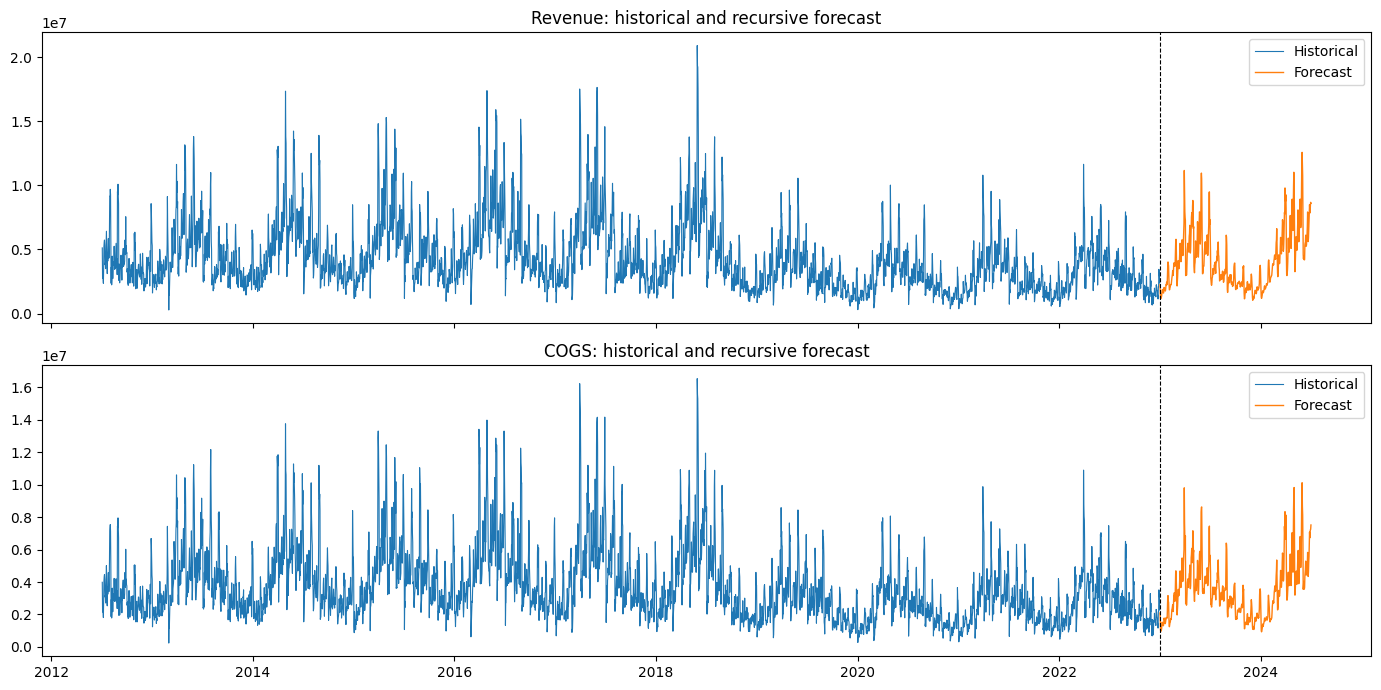

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, target in zip(axes, TARGET_COLS):
    ax.plot(daily_sales["Date"], daily_sales[target], label="Historical", linewidth=0.8)
    ax.plot(forecast["Date"], forecast[target], label="Forecast", linewidth=1.0)
    ax.axvline(FORECAST_START, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{target}: historical and recursive forecast")
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Explainability

This section exports feature importance and, when available, SHAP values. The narrative translates the strongest drivers into business language.

In [16]:
def extract_feature_importance(multioutput_model, feature_cols: list[str]) -> pd.DataFrame:
    rows = []
    for target, estimator in zip(TARGET_COLS, multioutput_model.estimators_):
        if hasattr(estimator, "feature_importances_"):
            importances = estimator.feature_importances_
        elif hasattr(estimator, "coef_"):
            importances = np.abs(estimator.coef_)
        else:
            continue
        for feature, importance in zip(feature_cols, importances):
            rows.append({"target": target, "feature": feature, "importance": float(importance)})
    out = pd.DataFrame(rows)
    if not out.empty:
        out["importance_share"] = out.groupby("target")["importance"].transform(lambda s: s / s.sum() if s.sum() else 0)
    return out.sort_values(["target", "importance"], ascending=[True, False]).reset_index(drop=True)

feature_importance = extract_feature_importance(final_model, feature_cols)
feature_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
feature_importance.groupby("target").head(12)

,target,feature,importance,importance_share
0,COGS,dayofmonth,1075.0,0.081507
1,COGS,COGS_lag_365,689.0,0.052241
2,COGS,COGS_lag_1,671.0,0.050876
3,COGS,COGS_lag_7,572.0,0.043369
4,COGS,COGS_lag_30,512.0,0.038820
5,COGS,Revenue_lag_365,463.0,0.035105
6,COGS,Revenue_lag_1,425.0,0.032224
7,COGS,COGS_lag_14,396.0,0.030025
8,COGS,Revenue_lag_7,377.0,0.028584
9,COGS,Revenue_lag_14,351.0,0.026613


In [17]:
try:
    import shap

    shap_summaries = []
    sample_X = X_val.sample(min(400, len(X_val)), random_state=RANDOM_SEED)
    for target, estimator in zip(TARGET_COLS, final_model.estimators_):
        explainer = shap.TreeExplainer(estimator)
        values = explainer.shap_values(sample_X)
        mean_abs = np.abs(values).mean(axis=0)
        shap_summaries.append(
            pd.DataFrame({"target": target, "feature": feature_cols, "mean_abs_shap": mean_abs})
        )
    shap_summary = pd.concat(shap_summaries, ignore_index=True).sort_values(["target", "mean_abs_shap"], ascending=[True, False])
    display(shap_summary.groupby("target").head(10))
except Exception as exc:
    shap_summary = pd.DataFrame()
    print("SHAP skipped:", repr(exc))

,target,feature,mean_abs_shap
111,COGS,COGS_lag_1,656121.780097
115,COGS,COGS_lag_365,361940.497546
73,COGS,dayofmonth,170832.149775
112,COGS,COGS_lag_7,130376.191976
90,COGS,Revenue_lag_1,113428.557458
113,COGS,COGS_lag_14,76199.316228
83,COGS,dayofweek_cos,62248.029478
94,COGS,Revenue_lag_365,53112.948525
91,COGS,Revenue_lag_7,50586.796775
84,COGS,dayofyear_sin,47974.365956


In [18]:
def business_driver_summary(feature_importance: pd.DataFrame, top_n: int = 8) -> None:
    for target in TARGET_COLS:
        top_features = feature_importance.loc[feature_importance["target"] == target].head(top_n)["feature"].tolist()
        print(f"\n{target} major drivers")
        for feature in top_features:
            if "lag" in feature:
                explanation = "recent or same-season historical demand level"
            elif "roll_mean" in feature:
                explanation = "moving average demand trend"
            elif "roll_std" in feature:
                explanation = "recent volatility in sales levels"
            elif any(part in feature for part in ["dayofweek", "weekofyear", "month", "dayofyear"]):
                explanation = "calendar seasonality and shopping-cycle timing"
            elif "cogs_to_revenue" in feature or "gross_margin" in feature:
                explanation = "historical margin and cost relationship"
            else:
                explanation = "longer-term level or calendar structure"
            print(f"- {feature}: {explanation}")

business_driver_summary(feature_importance)


Revenue major drivers
- dayofmonth: calendar seasonality and shopping-cycle timing
- Revenue_lag_1: recent or same-season historical demand level
- COGS_lag_365: recent or same-season historical demand level
- Revenue_lag_7: recent or same-season historical demand level
- gross_margin_lag_1: recent or same-season historical demand level
- COGS_lag_1: recent or same-season historical demand level
- Revenue_lag_365: recent or same-season historical demand level
- cogs_to_revenue_lag_1: recent or same-season historical demand level

COGS major drivers
- dayofmonth: calendar seasonality and shopping-cycle timing
- COGS_lag_365: recent or same-season historical demand level
- COGS_lag_1: recent or same-season historical demand level
- COGS_lag_7: recent or same-season historical demand level
- COGS_lag_30: recent or same-season historical demand level
- Revenue_lag_365: recent or same-season historical demand level
- Revenue_lag_1: recent or same-season historical demand level
- COGS_lag_1

## 7. Reproducibility

The workflow uses a fixed random seed, stores validation results, and saves model configuration needed to reproduce the final run.

In [19]:
validation_table.to_csv(VALIDATION_RESULTS_PATH, index=False)

model_config = {
    "random_seed": RANDOM_SEED,
    "target_cols": TARGET_COLS,
    "lags": LAGS,
    "rolling_windows": ROLLING_WINDOWS,
    "forecast_start": FORECAST_START.strftime("%Y-%m-%d"),
    "forecast_end": FORECAST_END.strftime("%Y-%m-%d"),
    "validation_year": VALIDATION_YEAR,
    "feature_count": len(feature_cols),
    "final_model_library": final_library,
    "final_model_params": best_boosting["params"],
    "best_validation_avg_rmse": best_score,
    "submission_path": str(SUBMISSION_PATH.relative_to(PROJECT_ROOT)),
    "validation_results_path": str(VALIDATION_RESULTS_PATH.relative_to(PROJECT_ROOT)),
    "feature_importance_path": str(FEATURE_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)),
}

MODEL_CONFIG_PATH.write_text(json.dumps(model_config, indent=2), encoding="utf-8")

print("Saved validation results:", VALIDATION_RESULTS_PATH)
print("Saved model config:", MODEL_CONFIG_PATH)
print("Saved feature importance:", FEATURE_IMPORTANCE_PATH)
model_config

Saved validation results: D:\Project\DATATHON-2026-r1\reports\tables\03_sales_forecast_validation_results.csv
Saved model config: D:\Project\DATATHON-2026-r1\models\03_sales_forecast_model_config.json
Saved feature importance: D:\Project\DATATHON-2026-r1\reports\tables\03_sales_forecast_feature_importance.csv


{'random_seed': 42,
 'target_cols': ['Revenue', 'COGS'],
 'lags': [1, 7, 14, 30, 365],
 'rolling_windows': [7, 30, 90, 365],
 'forecast_start': '2023-01-01',
 'forecast_end': '2024-07-01',
 'validation_year': 2022,
 'feature_count': 68,
 'final_model_library': 'lightgbm',
 'final_model_params': {'n_estimators': 800,
  'learning_rate': 0.02,
  'max_depth': 5,
  'num_leaves': 45,
  'subsample': 0.9,
  'colsample_bytree': 0.8},
 'best_validation_avg_rmse': 721490.2706388216,
 'submission_path': 'submissions\\submission_03_sales_forecast.csv',
 'validation_results_path': 'reports\\tables\\03_sales_forecast_validation_results.csv',
 'feature_importance_path': 'reports\\tables\\03_sales_forecast_feature_importance.csv'}